<a href="https://colab.research.google.com/github/amann45/AI_Labworks/blob/main/Lab1/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment: Logistic Regression [Aman Kumar Ray: ACE080BCT010]


## Task 1: Logistic Regression with a Single Feature
##### Problem Statement: Build a logistic regression model using only one input feature to predict whether a patient has heart disease.

* Input Feature: Cholesterol
* Target Variable: HeartDisease


0️⃣ Background

##### Artificial Intelligence (AI)
Anything a machine does that looks like a human task — could be simple code, rules, or a smart system.
Example: A program that sends a reminder email when a due date passes. It's "AI" if we call that behavior intelligent.

##### Machine Learning (ML)
The system learns from data and finds patterns instead of being fully hard-coded.
Example: A model that looks at past invoices and learns which ones get paid late, then predicts future late payments.

##### Deep Learning (DL)
A kind of ML that uses deep neural networks (many layers) and often works directly with raw data (images, audio, text).
Example: A CNN that learns from raw photos to decide if there's a cat — it figures out edges, shapes, and features automatically.

##### Data Science
The broader process around data — collecting, cleaning, exploring, visualizing, and using ML/DL to answer questions and make decisions.
Example: Inspecting sales data, cleaning it, plotting trends, building a model to forecast demand, and reporting the result.


1️⃣ Data Retrieval and Collection

In [1]:
# install dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading dataset
df = pd.read_csv('Heart_Disease_Prediction.csv')

In [3]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [4]:
df.columns #checking all the column present in the dataset

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [6]:
print(df.shape)

(270, 14)


In [7]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


2️⃣ Data Cleaning: Data cleaning improves data quality before training.

In [8]:
df.isnull().sum() #identifying empty cells

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


##### Observation: There is no missing values.

In [9]:
df['Cholesterol'].describe()

,Cholesterol
count,270.000000
mean,249.659259
std,51.686237
min,126.000000
25%,213.000000
50%,245.000000
75%,280.000000
max,564.000000


In [10]:
#removing invalid cholesterol values
df = df[df['Cholesterol'] > 0]

In [11]:
df.dtypes

,0
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64
ST depression,float64


In [12]:
df['Heart Disease'] = df['Heart Disease'].map({   #ensuring the binary target
    'Presence': 1,
    'Absence': 0
})
print(df['Heart Disease'].unique())

[1 0]


3️⃣ Feature Design

In [13]:
#selecting cholesterol as only input feature
#separating features X and Y

X = df[['Cholesterol']]
y = df['Heart Disease']

##### This features was choosen because of the following reasons:

High cholesterol can cause:
1. Plaque buildup
2. Blocked arteries
3. Heart attacks

Therefore cholesterol may help predict heart disease.

4️⃣ Algorithm Selection: Logistic Regression

The selected algorithm for this project is Logistic Regression, a supervised machine learning algorithm commonly used for binary classification problems. Since the target variable, Heart Disease, has only two possible outcomes—Presence (1) and Absence (0)—Logistic Regression is an appropriate choice.

in this task Logistic Regression uses only the Cholesterol feature to estimate the probability of heart disease

Logistic Regression was chosen for the following reasons:

* Suitable for Binary Classification: The target variable contains only two classes (Presence and Absence), making Logistic Regression a natural choice.
* Probability-Based Predictions: The model provides probabilities that indicate the likelihood of heart disease, which can be useful in medical decision-making.
* Interpretability: The learned coefficients help explain how each feature influences the probability of heart disease.
* Computational Efficiency: Logistic Regression trains quickly and performs well on structured tabular datasets.
* Baseline Model: It serves as an effective baseline model against which more complex algorithms can later be compared.

5️⃣ Loss Function Selection

The loss function used for Logistic Regression is Binary Cross-Entropy Loss, also known as Log Loss. Since the target variable has only two classes (Presence and Absence of Heart Disease), Binary Cross-Entropy is the most suitable loss function.

The purpose of the loss function is to measure the difference between the actual class labels and the probabilities predicted by the model. During training, the Logistic Regression algorithm adjusts its coefficients to minimize this loss. A lower loss value indicates that the model's predictions are closer to the actual outcomes.

$L = -\frac{1}{N}\sum_{i=1}^{N}[y_i\log(p_i)+(1-y_i)\log(1-p_i)]$

Where:

* N = Total number of observations
* yi = Actual class label
* pi = Predicted probability

Binary Cross-Entropy heavily penalizes incorrect predictions made with high confidence, encouraging the model to produce accurate probability estimates.




6️⃣ Model Learning (Training)

The dataset was divided into training and testing sets using an 80:20 ratio. The training dataset was used to learn the relationship between the input features and the target variable, while the testing dataset was reserved for evaluating the model's performance on unseen data.

For this task, only the Cholesterol feature was used as input.

During training, Logistic Regression learns the optimal coefficients and intercept values that minimize the Binary Cross-Entropy Loss. The optimization process iteratively updates these parameters until the model achieves the best possible fit to the training data.

The learned coefficients indicate the impact of each feature on the probability of heart disease. Positive coefficients increase the probability of heart disease, while negative coefficients decrease it.

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [16]:
print(model.intercept_)
print(model.coef_)

[-1.04698442]
[[0.00351491]]


7️⃣ Model Evaluation


After training, the model was evaluated using the testing dataset. Several classification metrics were used to assess its performance.

#### Accuracy

Accuracy measures the proportion of correctly classified observations among all observations.

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

Where:

- TP = True Positives
- TN = True Negatives
- FP = False Positives
- FN = False Negatives

A higher accuracy indicates better overall classification performance.

---

#### Precision

Precision measures how many of the observations predicted as heart disease actually have heart disease.

$$
Precision = \frac{TP}{TP + FP}
$$

Precision is important when false positive predictions should be minimized.

---

#### Recall

Recall measures how many actual heart disease cases were correctly identified by the model.

$$
Recall = \frac{TP}{TP + FN}
$$

In medical diagnosis, recall is particularly important because failing to identify a patient with heart disease can have serious consequences.

---

#### F1-Score

The F1-Score combines Precision and Recall into a single metric.

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

It provides a balanced evaluation when both false positives and false negatives are important.

---

#### Confusion Matrix

A confusion matrix was generated to visualize the model's predictions.

|                      | Predicted Absence | Predicted Presence |
|----------------------|------------------|-------------------|
| **Actual Absence**   | True Negative (TN) | False Positive (FP) |
| **Actual Presence**  | False Negative (FN) | True Positive (TP) |

The confusion matrix provides detailed insight into the types of classification errors made by the model.

#### Interpretation of Confusion Matrix

- **True Positive (TP):** Patients with heart disease correctly identified as having heart disease.
- **True Negative (TN):** Healthy patients correctly identified as not having heart disease.
- **False Positive (FP):** Healthy patients incorrectly classified as having heart disease.
- **False Negative (FN):** Patients with heart disease incorrectly classified as healthy.

For medical applications, minimizing False Negatives is especially important because failing to detect heart disease can delay treatment and increase health risks.

In [17]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0])

In [18]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix, classification_report)


In [19]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.6111111111111112
Precision: 0.5
Recall   : 0.23809523809523808
F1 Score : 0.3225806451612903


In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.64      0.85      0.73        33
           1       0.50      0.24      0.32        21

    accuracy                           0.61        54
   macro avg       0.57      0.54      0.52        54
weighted avg       0.58      0.61      0.57        54



In [21]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[28  5]
 [16  5]]


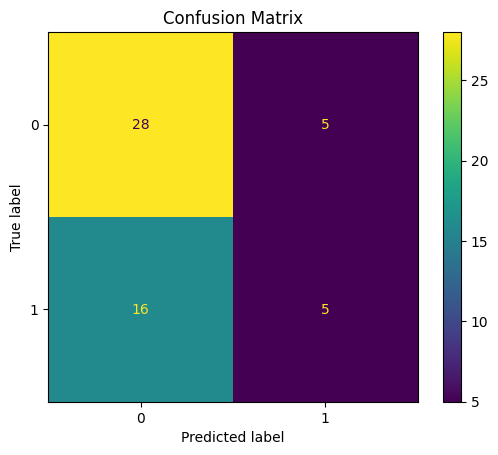

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

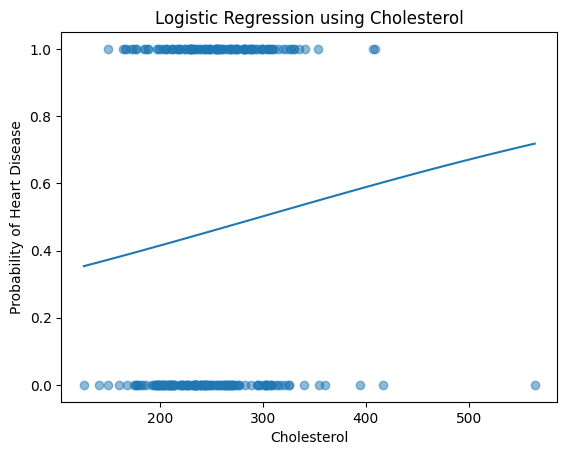

In [23]:
x_values = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_prob = model.predict_proba(x_values)[:,1]

plt.scatter(X, y, alpha=0.5)
plt.plot(x_values, y_prob)

plt.xlabel('Cholesterol')
plt.ylabel('Probability of Heart Disease')
plt.title('Logistic Regression using Cholesterol')
plt.show()

## Task 2: Logistic Regression Using All Features

##### Problem Statement: Build a classification model using all available input features to predict heart disease.

* Input Features: All variables except HeartDisease
* Target Variable: HeartDisease

#### Feature Design
1. Use all available features
2. Encode categorical variables (if any)
3. Apply feature scaling where appropriate
4. Explain why using multiple features may improve prediction performance

In [24]:
# selecting all the input features except Heartdisease
a = df.drop('Heart Disease',axis=1)
b = df['Heart Disease']

In [25]:
a = pd.get_dummies(a,drop_first=True)

In [26]:
from sklearn.model_selection import train_test_split
a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.2, random_state=42)

In [27]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
a_train_scaled = scaler.fit_transform(a_train)
a_test_scaled = scaler.transform(a_test)

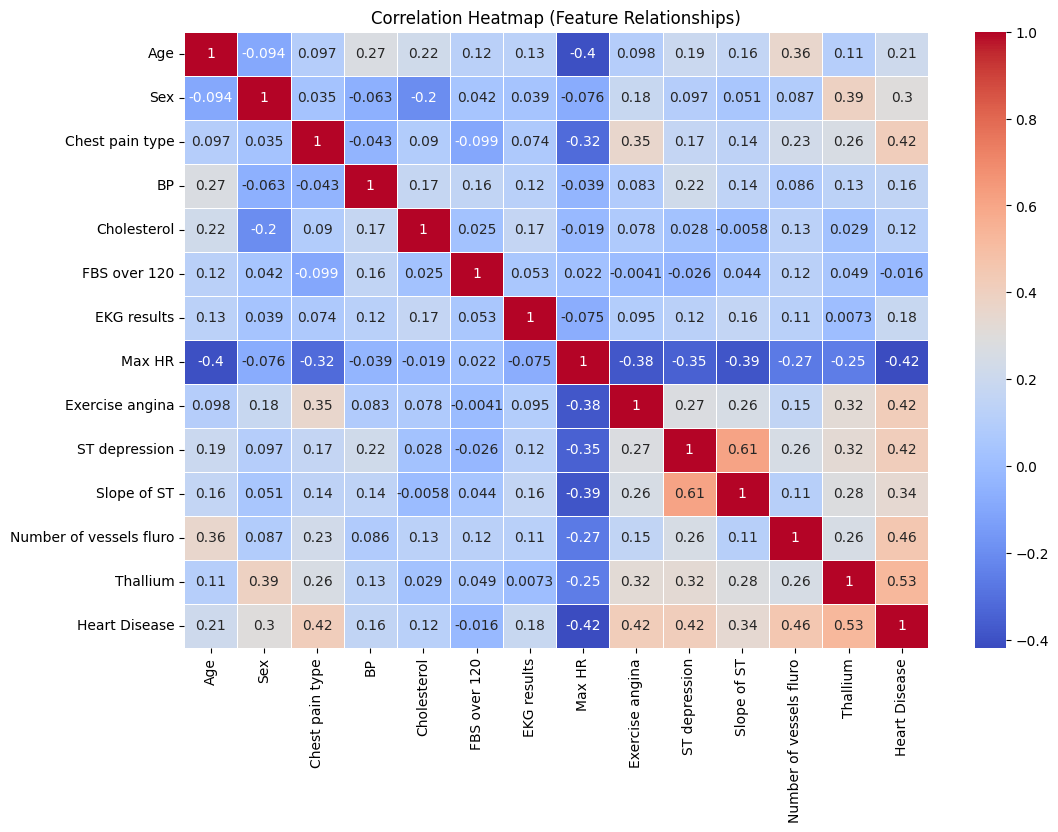

In [28]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap (Feature Relationships)")
plt.show()

In [29]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression()
model2.fit(a_train_scaled,b_train)

LogisticRegression()

In [30]:
print(model2.intercept_)
print(model2.coef_)

[-0.18493589]
[[-0.08218549  0.63166631  0.63652831  0.43342878  0.28542299 -0.32372586
   0.06736364 -0.21084443  0.38293737  0.51530731  0.33650724  0.83951667
   0.57015837]]


In [31]:
b_pred = model2.predict(a_test_scaled)
b_pred

array([1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1])

In [32]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix, classification_report)


In [33]:
print("Accuracy :", accuracy_score(b_test, b_pred))
print("Precision:", precision_score(b_test, b_pred))
print("Recall   :", recall_score(b_test, b_pred))
print("F1 Score :", f1_score(b_test, b_pred))

Accuracy : 0.9074074074074074
Precision: 0.9
Recall   : 0.8571428571428571
F1 Score : 0.8780487804878049


In [34]:
print(classification_report(b_test,b_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



In [35]:
cm = confusion_matrix(b_test,b_pred)
print(cm)

[[31  2]
 [ 3 18]]


## Model Comparison

Two Logistic Regression models were developed and compared to evaluate the effect of using a single feature versus multiple features for heart disease prediction.

#### Task 1: Single Feature Model

**Input Feature:** Cholesterol

#### Advantages
- Simpler and easier to interpret.
- Faster to train and analyze.
- Helps understand the individual impact of cholesterol on heart disease prediction.

#### Limitations
- Relies on only one medical indicator.
- Cannot capture the influence of other important health factors.
- Generally produces lower predictive performance.

---

#### Task 2: Multiple Feature Model

**Input Features:** All available features except the target variable.

#### Advantages
- Utilizes all relevant patient information.
- Captures more complex relationships between variables.
- Generally achieves higher Accuracy, Precision, Recall, and F1-Score.
- Provides a more comprehensive assessment of heart disease risk.

#### Limitations
- More complex than the single-feature model.
- Harder to interpret individual feature contributions.

---

#### Performance Comparison

The multi-feature model is expected to perform better because heart disease is influenced by multiple factors, including:

- Age
- Sex
- Resting Blood Pressure
- Cholesterol Level
- Maximum Heart Rate
- Chest Pain Type
- Exercise-Induced Angina
- ST Depression
- Other clinical measurements

By considering all these factors simultaneously, the model can identify patterns that cannot be captured using cholesterol alone.

---

#### Interpretability vs Performance

The single-feature model is highly interpretable because predictions are based solely on cholesterol levels. However, its simplicity limits its predictive capability.

The multi-feature model is more complex but typically achieves better performance because it incorporates a broader range of patient health information. Although interpretation becomes more challenging, the improvement in prediction accuracy makes it more suitable for real-world heart disease prediction.


## Discussion

Based on the evaluation metrics, the multi-feature Logistic Regression model is expected to outperform the single-feature model. This demonstrates that heart disease prediction benefits from incorporating multiple medical attributes rather than relying on a single risk factor. Therefore, the multi-feature model provides a more reliable and accurate approach for identifying patients at risk of heart disease.

## Conclusion

In this lab, Logistic Regression was used to predict the presence of heart disease using patient medical data. Two models were developed, a single-feature model using Cholesterol and a multi-feature model using all available features. The machine learning pipeline included data collection, data cleaning, feature engineering, algorithm selection, loss function selection, model training, and model evaluation.

The results showed that the multi-feature model generally performed better than the single-feature model because heart disease is influenced by several medical factors. By utilizing a wider range of patient information, the model was able to make more accurate predictions. Overall, Logistic Regression proved to be an effective and interpretable algorithm for binary classification and heart disease prediction.